# Rastair built-in model evaluation

In [20]:
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(caret)
  library("ggVennDiagram")
})
params <- list(threads=6,
               test_chr="chr12",
               rastair2 = "target/release/rastair2",
               test_fasta = "Analysis/data/chr12.fasta.gz",
               test_bam = "Analysis/data/aaf06_chr12.bam")

## Load data

In [21]:
truth.set <- fread(cmd=paste0("bcftools query -r ", params$test_chr, " -f '%CHROM\\t%POS\\t%REF\\t%ALT[\\t%GT]\\n' -i 'TYPE=\"SNP\" & FILTER=\"PASS\"' Analysis/data/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz"), header=FALSE, stringsAsFactors = TRUE)
setnames(truth.set, c("chr", "pos", "ref", "alt", "genotype"))

# subset truth set to regions that could have been called at all - not fair to compare regions without coverage
setkey(truth.set, chr, pos, ref, alt)

Run rastair2 call and extract relevant info

In [22]:
predictions.r2 <- fread(cmd=paste(params$rastair2, "call --vcf - -@", params$threads, "--ml 0.8 -l", params$test_chr, "-r", params$test_fasta, params$test_bam, " | bcftools query -f '%CHROM\\t%POS\\t%REF\\t%ALT\\t%FILTER\\t%CPG\\t%CPGnovo[\\t%DP\\t%ML]\\n'"), header=FALSE, stringsAsFactors=TRUE, na.strings = c(".", "", "NA", "NaN", "*", "<*>"))
setnames(predictions.r2, c("chr", "pos", "ref", "alt", "filter", "cpg", "dn_cpg", "depth", "score"))

In [23]:
predictions.r2[is.na(cpg), cpg := 0]
predictions.r2[is.na(dn_cpg), dn_cpg := 0]
predictions.r2 <- predictions.r2[!is.na(alt)]

## Compare overlap of calls

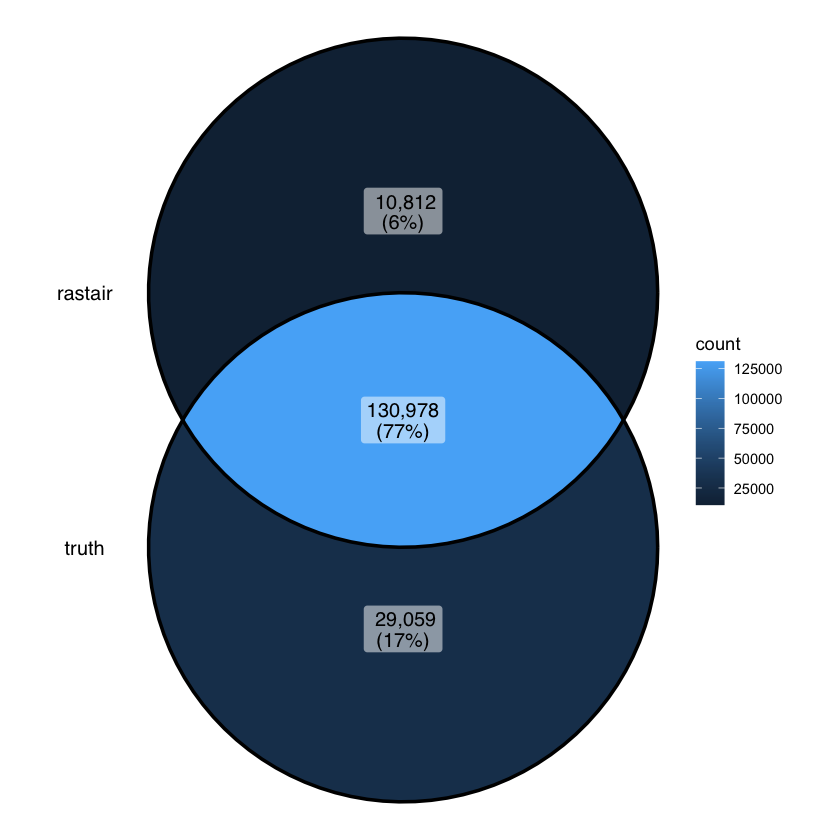

In [24]:
setkey(truth.set, chr, pos, ref, alt)
setkey(predictions.r2, chr, pos, ref, alt)

ggVennDiagram(list(truth=truth.set[chr==params$test_chr, paste0(chr, ":", pos, " ", ref, ">", alt)], rastair=predictions.r2[filter=="PASS", paste0(chr, ":", pos, " ", ref, ">", alt)]))

This is starting to look better but still not quite right. Still a slightly higher false-positive and false negative rate than I thought we'd get, based on the R results.

Let's calculate the statistics properly:

In [25]:
predictions.r2.true <- truth.set[, .(chr, pos, ref, alt, type="SNP")][predictions.r2]
predictions.r2.true[is.na(type), type := "REF"]
predictions.r2.true[, type := as.factor(type)]

cm.stats <- confusionMatrix(predictions.r2.true[, as.factor(fifelse(filter=="PASS", "SNP", "REF"))], reference = predictions.r2.true$type, positive="SNP")
cm.stats

Confusion Matrix and Statistics

          Reference
Prediction      REF      SNP
       REF 11773552    15972
       SNP    10812   130978
                                          
               Accuracy : 0.9978          
                 95% CI : (0.9977, 0.9978)
    No Information Rate : 0.9877          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9061          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.89131         
            Specificity : 0.99908         
         Pos Pred Value : 0.92375         
         Neg Pred Value : 0.99865         
             Prevalence : 0.01232         
         Detection Rate : 0.01098         
   Detection Prevalence : 0.01188         
      Balanced Accuracy : 0.94520         
                                          
       'Positive' Class : SNP             


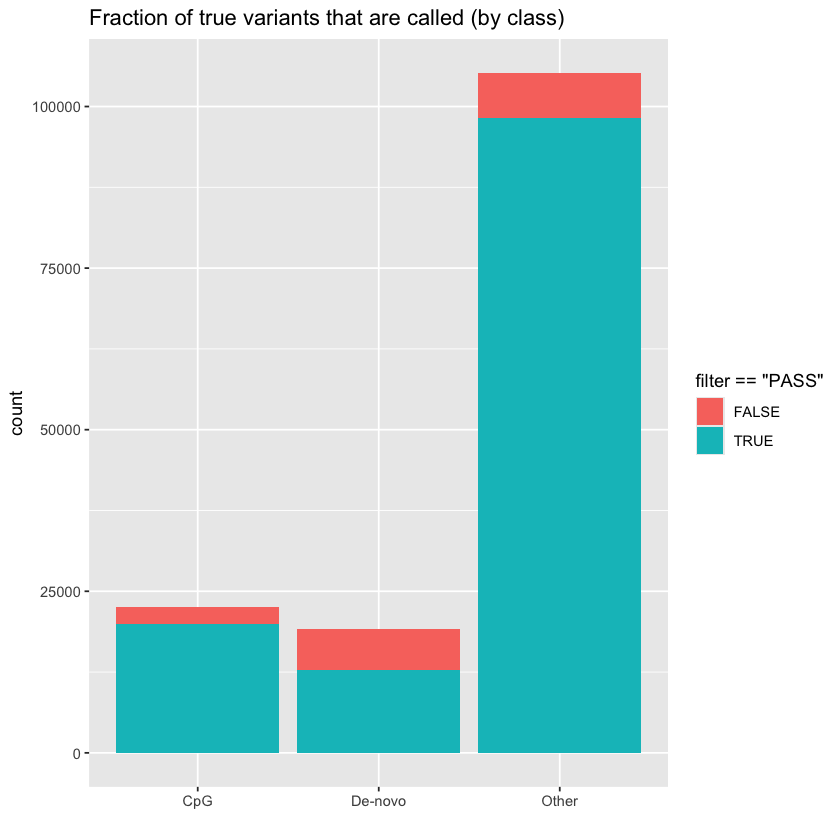

In [26]:
ggplot(predictions.r2.true[type=="SNP"], aes(x=ifelse(cpg, "CpG", ifelse(dn_cpg, "De-novo", "Other")), fill=filter=="PASS")) + geom_bar() + xlab("") + ggtitle("Fraction of true variants that are called (by class)")

In [31]:
cm.stats <- confusionMatrix(predictions.r2.true[dn_cpg==FALSE & cpg==TRUE, as.factor(fifelse(filter=="PASS", "SNP", "REF"))], reference = predictions.r2.true[dn_cpg==FALSE & cpg==TRUE]$type, positive="SNP")
cm.stats

Confusion Matrix and Statistics

          Reference
Prediction     REF     SNP
       REF 2072825    2661
       SNP    1816   19879
                                          
               Accuracy : 0.9979          
                 95% CI : (0.9978, 0.9979)
    No Information Rate : 0.9893          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.8977          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.881943        
            Specificity : 0.999125        
         Pos Pred Value : 0.916294        
         Neg Pred Value : 0.998718        
             Prevalence : 0.010748        
         Detection Rate : 0.009479        
   Detection Prevalence : 0.010345        
      Balanced Accuracy : 0.940534        
                                          
       'Positive' Class : SNP             
      